In [1]:
from prod_fs import ProD

import numpy as np
import pandas as pd

from sklearn.datasets import make_classification

from matplotlib import rc
import matplotlib.pyplot as plt
plt.rcParams['font.serif'] = ['CMU Serif']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.size'] = 11

# Create random classification dataset
X, y = make_classification(
    n_samples=300, n_features=50, n_classes=3, n_informative=5,
    shuffle=False
)

# Initialize ProD object using Silverman's rule-of-thumb for univariate data
prod_silvermanROT = ProD(bw_method="silverman_rot")

# Initialize ProD object using the default Scott's rule
prod_scott = ProD(bw_method="scott")

In [2]:
# Carry out feature selection using both rankers
prod_silvermanROT.fit(X, y)
prod_scott.fit(X, y)

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'


In [3]:
# Get top 10 features from both rankers
df_topfeatures = pd.DataFrame(columns=["Scott", "SilvermanROT"])
df_topfeatures["Scott"]        = prod_scott.get_topnFeatures(10)
df_topfeatures["SilvermanROT"] = prod_silvermanROT.get_topnFeatures(10)

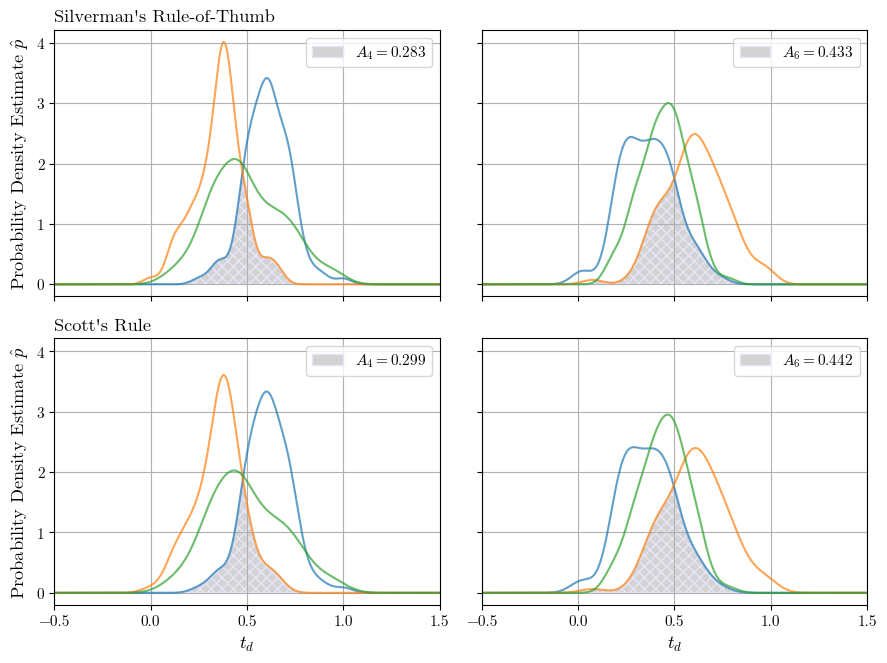

In [6]:
# Visualize the top feature's ability to segregate PDEs
plotlength = 9.0
fig, axs = plt.subplots(
    2, 2, sharex=True, sharey=True, figsize=(plotlength, plotlength/1.33)
)

# 2 top ranks features from Silverman's ROT
prod_silvermanROT.plot_overlapAreas(df_topfeatures.at[0, "SilvermanROT"], legend="intersection", _ax=axs[0,0])
prod_silvermanROT.plot_overlapAreas(df_topfeatures.at[1, "SilvermanROT"], legend="intersection", _ax=axs[0,1])
axs[0,0].set_title("Silverman's Rule-of-Thumb", loc="left")

# 2 top ranks features from Scott's rule
prod_scott.plot_overlapAreas(df_topfeatures.at[0, "Scott"], legend="intersection", _ax=axs[1,0])
prod_scott.plot_overlapAreas(df_topfeatures.at[1, "Scott"], legend="intersection", _ax=axs[1,1])
axs[1,0].set_title("Scott's Rule", loc="left")

axs[0,0].set_ylabel(r"Probability Density Estimate $\hat{p}$", fontsize="large")
axs[1,0].set_ylabel(r"Probability Density Estimate $\hat{p}$", fontsize="large")
for i in range(2):
    axs[i,0].set_xlim(-0.5, 1.5)
    axs[i,0].set_xticks(np.arange(-0.5, 2.0, 0.5))
    for j in range(2):
        axs[i,j].grid()

# x-label
axs[0,0].set_xlabel("")
axs[0,1].set_xlabel("")
axs[1,0].set_xlabel(r"$t_d$")
axs[1,1].set_xlabel(r"$t_d$")

fig.tight_layout()